#Neural network from scratch

##1. Imports

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # For basic plotting
from sklearn.datasets import fetch_openml

# Descargar MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)


In [174]:
# importar libreria para visualización seaborn
import seaborn as sns

In [175]:
type(mnist)
print(mnist.keys())
print(isinstance(mnist, dict))

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
True


In [176]:
# Separar en datos y etiquetas
X, y = mnist.data, mnist.target

# Ver dimensiones
print(f"Data shape: {X.shape}, Labels shape: {y.shape}")

Data shape: (70000, 784), Labels shape: (70000,)


In [177]:
#Halla el tipo de datos en el array X
print(X.dtype)

int64


In [178]:
#halla el valor maximo en el array X
print(np.max(X))

255


In [179]:
# Redimensionar 'y' para que sea una matriz de columna (70000, 1)
y = y.reshape(-1, 1)

# Concatenar 'y' como primera columna
mnist_combined = np.hstack((y, X))

# Ver la nueva forma del dataset
print(mnist_combined.shape)  # (70000, 785)

(70000, 785)


In [180]:
max_value = max(y)

print("Maximum value:", max_value)

#mnist_combined[:][0]

#max_value = max(max(row) for row in mnist_combined)

#print("Maximum value:", max_value)

Maximum value: ['9']


In [181]:
def printNum(number):

  number = np.array(number, dtype=int)  # Convertir a NumPy array con tipo float

  # Extraer la etiqueta (primera columna)
  label = number[0]

  # Extraer los píxeles y reestructurar a 28x28
  image = number[1:].reshape(28, 28)


  # Mostrar la imagen
  plt.imshow(image, cmap='gray')
  plt.title(f"Label: {int(label)}")  # Convertimos a entero para mostrar bien el número
  plt.axis("off")  # Ocultar los ejes
  plt.show()

In [182]:
mnist_combined[0].shape

(785,)

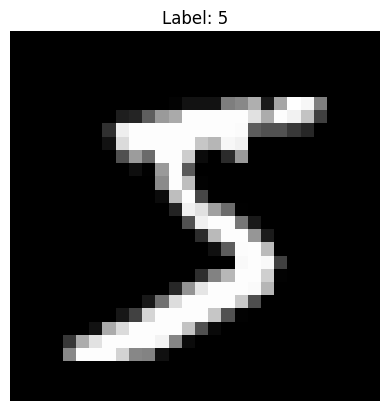

In [183]:
printNum(mnist_combined[0])

In [184]:
# Barajar aleatoriamente las filas de mnist_combined
# Set seed for reproducibility
np.random.seed(42)
np.random.shuffle(mnist_combined)

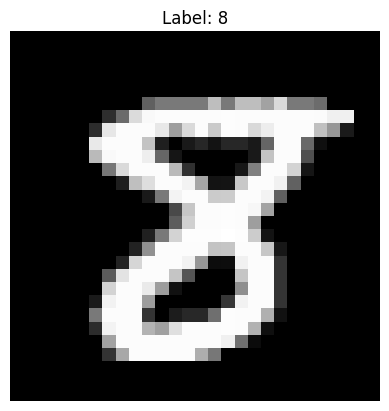

In [185]:
printNum(mnist_combined[0])

In [186]:
mnist_test=mnist_combined[:10000]
mnist_train=mnist_combined[10000:]

print(mnist_test.shape)
print(mnist_train.shape)

(10000, 785)
(60000, 785)


## 2. Preprocesamiento

In [187]:
# Make batches on the mnist_train dataset of 100 rows each, randomize it

# Set seed for reproducibility
np.random.seed(42)

# Shuffle dataset
np.random.shuffle(mnist_train)

# Create batches of 100
batch_size = 100
num_batches = len(mnist_train) // batch_size

batches = [mnist_train[i * batch_size:(i + 1) * batch_size] for i in range(num_batches)]

# Check batch shape
print(f"Total batches: {len(batches)}")
print(f"Shape of a batch: {batches[0].shape}")  # Should be (100, 785) -> 784 features + 1 label




Total batches: 600
Shape of a batch: (100, 785)


In [188]:
type(batches)

list

## 3. Creación de la red neuronal

In [189]:
class Neural_network:
    def __init__(self, n0, n1, n2):
        # Inicialización de los pesos (W) y sesgos (b)
        ''' DESCOMENTAR LUEGO, POR EL MOMENTO LO DE ABAJO ES PARA QUE ME DE ENTEROS
        np.random.seed(42)
        self.W1 = np.random.randn(n1, n0)  # Matriz W1 de tamaño (n1, n0)
        np.random.seed(42)
        self.b1 = np.random.randn(n1, 1)   # Vector b1 de tamaño (n1, 1)
        np.random.seed(42)
        self.W2 = np.random.randn(n2, n1)  # Matriz W2 de tamaño (n2, n1)
        np.random.seed(42)
        self.b2 = np.random.randn(n2, 1)   # Vector b2 de tamaño (n2, 1)
        '''
        np.random.seed(42)  # Fijar la semilla una sola vez

        # Generar matrices y vectores con números enteros entre -10 y 10
        self.W1 = np.random.randint(-10, 11, (n1, n0))  # Matriz W1 de tamaño (n1, n0)
        self.b1 = np.random.randint(-10, 11, (n1, 1))   # Vector b1 de tamaño (n1, 1)
        self.W2 = np.random.randint(-10, 11, (n2, n1))  # Matriz W2 de tamaño (n2, n1)
        self.b2 = np.random.randint(-10, 11, (n2, 1))   # Vector b2 de tamaño (n2, 1)
        self.cost = 0


In [190]:
# Ejemplo de uso
n0, n1, n2 = 784, 10, 10
nn = Neural_network(784, 10, 10)  # 3 neuronas en la capa de entrada, 4 en la oculta, 2 en la salida

# Verificando las dimensiones de las matrices y vectores creados
print("W1 shape:", nn.W1.shape)  # (4, 3)
print("b1 shape:", nn.b1.shape)  # (4, 1)
print("W2 shape:", nn.W2.shape)  # (2, 4)
print("b2 shape:", nn.b2.shape)  # (2, 1)

W1 shape: (10, 784)
b1 shape: (10, 1)
W2 shape: (10, 10)
b2 shape: (10, 1)


In [191]:
# Ejemplo de uso
n0_test, n1_test, n2_test = 2, 2, 2
nn_test = Neural_network(n0_test, n1_test, n2_test)  # 3 neuronas en la capa de entrada, 4 en la oculta, 2 en la salida

# Verificando las dimensiones de las matrices y vectores creados
print("W1 shape:", nn_test.W1.shape)  # (4, 3)
print("b1 shape:", nn_test.b1.shape)  # (4, 1)
print("W2 shape:", nn_test.W2.shape)  # (2, 4)
print("b2 shape:", nn_test.b2.shape)  # (2, 1)

W1 shape: (2, 2)
b1 shape: (2, 1)
W2 shape: (2, 2)
b2 shape: (2, 1)


In [192]:
#imprimir los valores de las matrices W1, b1, W2, b2
print("W1:\n", nn_test.W1)
print("b1:\n", nn_test.b1)
print("W2:\n", nn_test.W2)
print("b2:\n", nn_test.b2)

W1:
 [[-4  9]
 [ 4  0]]
b1:
 [[-3]
 [10]]
W2:
 [[-4  8]
 [ 0  0]]
b2:
 [[10]
 [-7]]


## 4. Forward Propagation

Definición de variables de entrada para NN_Test

In [193]:
# Definir el array de ejemplo
a0_test = np.array([[1, 2, 3], [4, 5, 6]])
print("El tamaño de a0_test es :", a0_test.shape)

# Separar el primer valor de cada fila
Y_test = a0_test[:, 0]  # Toma la primera columna
print("El tamaño original de Y es :", Y_test.shape)
Y_test = Y_test.reshape(2,1)
a0_test = a0_test[:, 1:]  # Toma todas las columnas excepto la primera

# Mostrar resultados
print("a0:", a0_test)  # [[2, 3], [5, 6]]
print("Y:", Y_test)  # [1, 4]
print("El tamaño de cada vector dentro de a0 es :", a0_test[0].shape)
print("El tamaño de Y es :", Y_test.shape)
print("El primer vector dentro de a0 es:", a0_test[0])

El tamaño de a0_test es : (2, 3)
El tamaño original de Y es : (2,)
a0: [[2 3]
 [5 6]]
Y: [[1]
 [4]]
El tamaño de cada vector dentro de a0 es : (2,)
El tamaño de Y es : (2, 1)
El primer vector dentro de a0 es: [2 3]


Definición de variables de entrada para NN

In [194]:
#Empiezo SOLO con el primer batch, cambiar esto!
#batch = batches[0]
#print("El tamaño del primer batch es: ", batch.shape)

#a0[0][0]) es el label, lo extraigo como Y y apartir de el creare el vector columna con 1 en la posición que debería
#y = a0[:, 0]
#print("El tamaño de y es: ", y.shape, " y es: ", y)

#Extraigo los 784 valores de entrada que srán a0
#a0 = a0[:, 1:]
#print(a0.shape)

#Ahora crearé el vector a0 para cada imagen, así como su vector "y" de 1s y 0s correspondiente



In [195]:
def relu(x):
    """Applies the ReLU activation function element-wise."""
    return np.maximum(0, x)

In [196]:
def relu_dif(x):
    """Computes the derivative of the ReLU activation function element-wise."""
    return np.where(x > 0, 1, 0)

In [197]:
def cost_function(a2, Y):
    """Computes the sum of squared differences (cost function)."""
    #print(a2)
    #print(Y)
    return np.sum((a2 - Y) ** 2)

In [198]:
def one_hot_encode(digit: str) -> np.ndarray:
    """
    Converts a digit (string) from '0' to '9' into a one-hot encoded vector of length 10.

    Args:
        digit (str): A single character string representing a digit from '0' to '9'.

    Returns:
        np.ndarray: A one-hot encoded vector of length 10.
    """
    if digit not in "0123456789":
        raise ValueError("Input must be a string representing a digit from '0' to '9'.")

    vector = np.zeros(10, dtype=int)
    vector[int(digit)] = 1
    return vector


In [199]:
#Forward prop de verdad
def forward_prop(nn, a0, Y): #Tener a0 y Y listos antes de pasar a esta función

  #print(a0.shape)
  #a0[0][0]) es el label, lo extraigo como Y y apartir de el creare el vector columna con 1 en la posición que debería
  #Y = batch[i, 0]
  print("y en forma de vector es: ", Y)

  #Extraigo los 784 valores de entrada que serán a0
  #a0 = batch[i, 1:]
  #print(a0.shape)

  z1 = nn.W1@a0 #Me aseguro de convertir a0 a vector columna
  z1 = z1.reshape(n1,1)
  #print("El tamaño de z1 es: ", z1.shape)
  z1 = z1+ nn.b1
  print(f"z1 en la iteración {i+1} es {z1}")

  a1=relu(z1)
  print(f"a1 en la iteración {i+1} es {a1}")

  z2 = nn.W2@a1
  z2 = z2.reshape(n2,1)
  z2 = z2 + nn.b2
  print(f"z2 en la iteración {i+1} es {z2}")


  a2=relu(z2)
  print(f"a2 en la iteración {i+1} es {a2}")

  #Y = one_hot_encode(Y).reshape(n2, 1)
  #print("El vector Y codificado es: ", y)

  cost = cost_function(a2, Y)
  print(f"El costo en la iteración {i+1} es {cost}")

  #print("Costo:", nn.cost)  # Salida esperada: 7937 para la primera
  #Hay que transformar el Y en lo de las imagenes

  return cost, a1, a2, z1, z2
  #print("Costo total:", nn.cost)

In [200]:
#Forward propagation by batch in the real NN - Esta hay que borrarla

#Hacer esto en forma de función

def forward_prop_test(nn, batch):

  for i in range(batch.shape[0]):

    #print(a0.shape)
    #a0[0][0]) es el label, lo extraigo como Y y apartir de el creare el vector columna con 1 en la posición que debería
    Y = batch[i, 0]
    print("y es: ", Y)

    #Extraigo los 784 valores de entrada que serán a0
    a0 = batch[i, 1:]
    #print(a0.shape)

    z1 = nn.W1@a0.reshape(n0, 1) #Me aseguro de convertir a0 a vector columna
    z1 = z1.reshape(n1,1)
    #print("El tamaño de z1 es: ", z1.shape)
    z1 = z1+ nn.b1
    #print(f"z1 en la iteración {i+1} es {z1}")

    a1=relu(z1)
    #print(f"a1 en la iteración {i+1} es {a1}")

    z2 = nn.W2@a1
    z2 = z2.reshape(n2,1)
    z2 = z2 + nn.b2
    #print(f"z2 en la iteración {i+1} es {z2}")


    a2=relu(z2)
    #print(f"a2 en la iteración {i+1} es {a2}")

    Y = one_hot_encode(Y).reshape(n2, 1)
    #print("El vector Y codificado es: ", y)

    nn.cost += cost_function(a2, Y)
    print(f"El costo en la iteración {i+1} es {cost_function(a2, Y)}")

    #print("Costo:", nn.cost)  # Salida esperada: 7937 para la primera
    #Hay que transformar el Y en lo de las imagenes

  cost = nn.cost / batch.shape[0]
  print("Costo promedio:", cost)
  cost_vector.append(cost)
  nn.cost = 0
  return cost_vector, a0, a1, a2, z1, z2, Y
  #print("Costo total:", nn.cost)

In [201]:
#EL backward de verdad
def backward_prop(nn, a0, a1, a2, z1, z2, Y):
  b2_var = 2 * (a2 - Y) * relu_dif(z2)
  #print(b2_var.shape)

  w2_var = b2_var @ a1.T
  #print(w2_var.shape)

  #b1_var = np.multiply(b2_var.T @ nn.W2, relu_dif(z1))
  b1_var = np.multiply(nn.W2.T @ b2_var, relu_dif(z1))
  #print(b1_var.shape)

  w1_var = b1_var @ a0.reshape(n0, 1).T
  #print(type(b1_var))
  #print(b1_var.shape)

  #print(w1_var.shape)

  return b2_var, w2_var, b1_var, w1_var

#EN algun lugar tengo que poder esto para reasignar los valores de la NN

#NN =backward_prop(NN)

In [202]:
#Ejemplo con solo un batch el batches[0]
delta = 0.001
#cost_acum = 0
cost_vector = []
#w1_acum = np.zeros((n1, n0))
#b1_acum = np.zeros((n1, 1))
#w2_acum = np.zeros((n2, n1))
#b2_acum = np.zeros((n2, 1))

#print(type(b1_var))
#print(b1_var.shape)

#for j in range(len(batches)): Quitar el comentario de esto later
for j in range(2):
  print(f"Batch {j+1}")

  #Inicializando en 0 las variables que van a tener el costo y los parametros de la NN acumulados para cada batch
  cost_acum = 0
  w1_acum = np.zeros((n1, n0))
  b1_acum = np.zeros((n1, 1))
  w2_acum = np.zeros((n2, n1))
  b2_acum = np.zeros((n2, 1))

  for i in range(batches[j].shape[0]):

    a0 = batches[j][i, 1:]
    a0 = a0.reshape(n0, 1)
    Y = batches[j][i, 0]
    print("Y es en valor numerico ",Y)
    Y = one_hot_encode(Y).reshape(n2, 1)
    #print("Y es en vector ",Y)
    cost, a1, a2, z1, z2 = forward_prop(nn, a0, Y)
    b2_var, w2_var, b1_var, w1_var = backward_prop(nn, a0, a1, a2, z1, z2, Y)
    #w1_var = np.array(w1_var)
    w1_acum = w1_acum + w1_var
    #b1_acum = np.array(b1_acum)
    b1_acum = b1_acum + b1_var
    w2_acum = w2_acum + w2_var
    b2_acum = b2_acum + b2_var
    cost_acum = cost_acum + cost

  w1_var_prom = w1_acum / batches[j].shape[0]
  b1_var_prom = b1_acum / batches[j].shape[0]
  w2_var_prom = w2_acum / batches[j].shape[0]
  b2_var_prom = b2_acum / batches[j].shape[0]
  print(f"El costo acumulado es: {cost_acum}")
  cost_prom = cost_acum / batches[j].shape[0]
  print(f"El costo promedio es: {cost_prom}")
  cost_vector.append(cost_prom)

  nn.W1 = nn.W1 - delta * w1_var_prom
  nn.b1 = nn.b1 - delta * b1_var_prom
  nn.W2 = nn.W2 - delta * w2_var_prom
  nn.b2 = nn.b2 - delta * b2_var_prom

  print(f"El costo promedio del batch es: {cost_prom}")

print(f"El tamaño del vector de costos es: {len(cost_vector)}")
print(f"El tamaño del vector de costos x 2 es: {len(cost_vector)}")


Streaming output truncated to the last 5000 lines.
 [0]
 [0]]
El costo en la iteración 4 es 1
Y es en valor numerico  4
y en forma de vector es:  [[0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]]
z1 en la iteración 5 es [[-4382858142.2447405]
 [-1260223065.0130603]
 [-471418556.61148006]
 [-9782131400.24264]
 [-10153273891.03894]
 [-11859722324.453285]
 [41013414.5679001]
 [-14656648264.180155]
 [-6098279852.9082985]
 [169904963.10766003]]
a1 en la iteración 5 es [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [41013414.5679001]
 [0]
 [0]
 [169904963.10766003]]
z2 en la iteración 5 es [[-44602913538681.46]
 [-280419247402994.84]
 [-141498783151546.03]
 [-119639275979048.47]
 [-1775225161.3763409]
 [-202520734402629.16]
 [-158827096474916.84]
 [-59144337819225.484]
 [-11532126664877.664]
 [-273487939456610.84]]
a2 en la iteración 5 es [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]
El costo en la iteración 5 es 1
Y es en valor numerico  1
y en forma de vector es:  [[0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]


In [104]:
print(f"El tamaño del vector de costos es: {len(cost_vector)}")
print(cost_vector)

El tamaño del vector de costos es: 5
[300684680033.55, 1.0, 1.0, 1.0, 1.0]


In [105]:
#print(batches[0].shape[0])
#Esto hay que arreglarlo, esta mal
'''
cost_vector = []

for i in range(len(batches)):
  print(f"Iteración {i+1}")
  cost_vector, a1, a2, z1, z2, Y = forward_prop(nn, batches[i])
  backward_prop(nn, a1, a2, z1, z2, Y)

#Empiezo SOLO con el primer batch, cambiar esto!
#batch = batches[0]
#print("El tamaño del primer batch es: ", batch.shape)
'''

'\ncost_vector = []\n\nfor i in range(len(batches)):\n  print(f"Iteración {i+1}")\n  cost_vector, a1, a2, z1, z2, Y = forward_prop(nn, batches[i])\n  backward_prop(nn, a1, a2, z1, z2, Y)\n\n#Empiezo SOLO con el primer batch, cambiar esto!\n#batch = batches[0]\n#print("El tamaño del primer batch es: ", batch.shape)\n'

In [106]:
#Forward propagation by batch in the test NN

for i in range(a0_test.shape[0]):

  z1_test = nn_test.W1@a0_test[i].reshape(n0_test, 1) #Me aseguro de convertir a0 a vector columna
  z1_test = z1_test.reshape(n1_test,1)
  z1_test = z1_test + nn_test.b1
  print(f"z1 en la iteración {i+1} es {z1_test}")

  a1_test=relu(z1_test)
  print(f"a1 en la iteración {i+1} es {a1_test}")

  z2_test = nn_test.W2@a1_test
  z2_test = z2_test.reshape(n2_test,1)
  z2_test = z2_test + nn_test.b2
  print(f"z2 en la iteración {i+1} es {z2_test}")

  a2_test=relu(z2_test)
  print(f"a2 en la iteración {i+1} es {a2_test}")

  nn_test.cost += cost_function(a2_test, Y_test)
  print(f"El costo en la iteración {i+1} es {cost_function(a2_test, Y_test)}")

  print("Costo:", nn_test.cost)  # Salida esperada: 7937 para la primera
  #Hay que transformar el Y en lo de las imagenes


z1 en la iteración 1 es [[16]
 [18]]
a1 en la iteración 1 es [[16]
 [18]]
z2 en la iteración 1 es [[90]
 [-7]]
a2 en la iteración 1 es [[90]
 [ 0]]
El costo en la iteración 1 es 7937
Costo: 7937
z1 en la iteración 2 es [[31]
 [30]]
a1 en la iteración 2 es [[31]
 [30]]
z2 en la iteración 2 es [[126]
 [ -7]]
a2 en la iteración 2 es [[126]
 [  0]]
El costo en la iteración 2 es 15641
Costo: 23578


### Testeo

In [107]:
z1 = nn_test.W1@a0[0]
z1 = z1.reshape(2,1)

print("z1 shape ", z1.shape)
print("W1 shape ", nn_test.W1.shape)
print("a0[0] ", a0[0].shape)



ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 2)

In [ ]:
z1

In [ ]:
print("nn_test.b1 shape", nn_test.b1.shape)
print("z1 shape ", z1.shape)
z1 = z1 + nn_test.b1

In [ ]:
print("z1 shape ", z1.shape)

In [ ]:
z1

In [ ]:
a1=relu(z1)
a1

In [ ]:
z2 = nn_test.W2@a1
z2 = z2.reshape(2,1)

print("z2 shape ", z2.shape)
print("W2 shape ", nn_test.W2.shape)
print("a1 ", a1.shape)

In [ ]:
z2 = z2 + nn_test.b2

In [ ]:
z2

In [ ]:
print("z2 shape ", z1.shape)

In [ ]:
a2=relu(z2)
a2

In [ ]:
Y = Y.reshape(2,1)
Y.shape


In [ ]:
Y

In [ ]:
cost = cost_function(a2, Y)
print("Costo:", cost)  # Salida esperada: 7937 para la primera iteración

###Split x and Y train and test

In [ ]:
'''
X_train = mnist_train [:, 1:mnist_train.shape[1]]
y_train = mnist_train [:, 0]
X_test = mnist_test [:, 1:mnist_test.shape[1]]
y_test = mnist_test [:, 0]

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
'''
